# NN VED to OBD2 Test

This notebook loads your already-saved VED neural-network artifacts from Google Drive and runs the model on the OBD2 logger CSV files.

Expected files in the VED folder:
- `ved_model.pth`
- `scaler_X.pkl`
- `scaler_y.pkl`
- `feature_names.json`

Important note:
- The OBD2 logger data has fuel-rate ground truth, so the notebook can score fuel-rate predictions.
- The OBD2 logger data does not have battery-SOC ground truth, so SOC is reported as inference-only.
- If the saved VED model expects features that do not exist in the OBD2 files, those missing features are filled with the training-set mean before scaling. That keeps the model runnable, but it also means prediction quality depends heavily on how many features overlap.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import glob
import bz2
import gzip
import json
import lzma
import pickle
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import torch
import torch.nn as nn

# Update these paths if your Drive layout is different.
VED_ARTIFACT_DIR = '/content/drive/MyDrive/Data/VED-dataset'
MODEL_PATH = f'{VED_ARTIFACT_DIR}/ved_model.pth'
SCALER_X_PATH = f'{VED_ARTIFACT_DIR}/scaler_X.pkl'
SCALER_Y_PATH = f'{VED_ARTIFACT_DIR}/scaler_y.pkl'
FEATURE_NAMES_PATH = f'{VED_ARTIFACT_DIR}/feature_names.json'

OBD2_GLOB = '/content/drive/MyDrive/Data/OBD2-datalogger/Fiesta-TD-Ci/*.csv'
PREDICTIONS_OUTPUT_PATH = f'{VED_ARTIFACT_DIR}/ved_obd2_predictions.csv'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Mounted at /content/drive
Using device: cpu


In [2]:
class HEVModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
        )

    def forward(self, x):
        return self.net(x)

def normalize_name(name):
    name = str(name).strip().lower()
    name = name.replace('[', ' ').replace(']', ' ')
    name = name.replace('(', ' ').replace(')', ' ')
    name = name.replace('%', ' percent ')
    name = name.replace('/', ' ')
    name = re.sub(r'[^a-z0-9]+', '_', name)
    return re.sub(r'_+', '_', name).strip('_')

def resolve_alias(columns, aliases):
    normalized = {normalize_name(col): col for col in columns}
    for alias in aliases:
        match = normalized.get(normalize_name(alias))
        if match is not None:
            return match
    return None

def identity(series):
    return pd.to_numeric(series, errors='coerce')

def fahrenheit_to_celsius(series):
    values = pd.to_numeric(series, errors='coerce')
    return (values - 32.0) * (5.0 / 9.0)

def mph_to_kmh(series):
    values = pd.to_numeric(series, errors='coerce')
    return values * 1.60934

def inhg_to_kpa(series):
    values = pd.to_numeric(series, errors='coerce')
    return values * 3.38639

def gal_per_hr_to_l_per_hr(series):
    values = pd.to_numeric(series, errors='coerce')
    return values * 3.78541

OBD2_FEATURE_RULES = {
    'Calculated load value (%)': {
        'aliases': [
            'Calculated load value (%)',
            'Calculated load value [%]',
            'Calculated load value',
            'Engine load (%)',
            'Engine load [%]',
            'Load (%)',
            'Load [%]'
        ],
        'transform': identity,
    },
    'Engine coolant temperature (°F)': {
        'aliases': [
            'Engine coolant temperature (C)',
            'Engine coolant temperature [C]',
            'Coolant temperature (C)',
            'Coolant temperature [C]'
        ],
        'transform': fahrenheit_to_celsius,
    },
    'Intake manifold absolute pressure (inHg)': {
        'aliases': [
            'Intake manifold absolute pressure (kPa)',
            'Intake manifold absolute pressure [kPa]',
            'Manifold absolute pressure (kPa)',
            'Manifold absolute pressure [kPa]',
            'MAP (kPa)',
            'MAP [kPa]'
        ],
        'transform': inhg_to_kpa,
    },
    'Vehicle speed (MPH)': {
        'aliases': [
            'Vehicle speed (km/h)',
            'Vehicle speed [km/h]',
            'Speed (km/h)',
            'Speed [km/h]',
            'Vehicle speed'
        ],
        'transform': mph_to_kmh,
    },
    'Latitude (deg)': {
        'aliases': ['Latitude (deg)', 'Latitude'],
        'transform': identity,
    },
    'Longitude (deg)': {
        'aliases': ['Longitude (deg)', 'Longitude'],
        'transform': identity,
    },
}

def load_feature_names(path):
    with open(path, 'r') as fh:
        payload = json.load(fh)

    if isinstance(payload, list):
        return payload

    if isinstance(payload, dict):
        for key in ['feature_names', 'features', 'columns']:
            if key in payload:
                return payload[key]

    raise ValueError('feature_names.json must contain either a list or a dict with a feature_names-like key.')

def load_pickle(path):
    loaders = [
        ('joblib', lambda p: joblib.load(p)),
        ('pickle', lambda p: pickle.load(open(p, 'rb'))),
        ('gzip+pickle', lambda p: pickle.load(gzip.open(p, 'rb'))),
        ('bz2+pickle', lambda p: pickle.load(bz2.open(p, 'rb'))),
        ('lzma+pickle', lambda p: pickle.load(lzma.open(p, 'rb'))),
        ('torch', lambda p: torch.load(p, map_location='cpu')),
    ]

    errors = []
    for name, loader in loaders:
        try:
            return loader(path)
        except Exception as exc:
            errors.append(f'{name}: {type(exc).__name__}: {exc}')

    with open(path, 'rb') as fh:
        header = fh.read(16)
    raise ValueError(
        f'Could not load artifact: {path}\n'
        f'First 16 bytes: {header!r}\n'
        'Tried loaders:\n- ' + '\n- '.join(errors)
    )

def load_model(model_path, input_dim, output_dim, device):
    raw = torch.load(model_path, map_location=device)
    state_dict = raw['model_state_dict'] if isinstance(raw, dict) and 'model_state_dict' in raw else raw
    model = HEVModel(input_dim=input_dim, output_dim=output_dim).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def load_obd2_data(obd2_glob):
    files = sorted(glob.glob(obd2_glob))
    if not files:
        raise FileNotFoundError(f'No OBD2 CSV files found for: {obd2_glob}')

    frames = []
    for file in files:
        frame = pd.read_csv(file, skiprows=1, encoding='utf-8-sig', skipinitialspace=True)
        frame['source_file'] = Path(file).name
        frames.append(frame)

    obd2_df = pd.concat(frames, ignore_index=True)
    print('Loaded OBD2 rows:', len(obd2_df))
    return obd2_df

def build_feature_mapping(obd2_columns, saved_feature_names):
    mapping = []
    for obd2_col, rule in OBD2_FEATURE_RULES.items():
        if obd2_col not in obd2_columns:
            continue
        saved_feature = resolve_alias(saved_feature_names, rule['aliases'])
        if saved_feature is not None:
            mapping.append({
                'obd2_col': obd2_col,
                'saved_feature': saved_feature,
                'transform': rule['transform'],
            })
    return mapping


In [3]:
feature_names = load_feature_names(FEATURE_NAMES_PATH)
scaler_X = load_pickle(SCALER_X_PATH)
scaler_y = load_pickle(SCALER_Y_PATH)

print('Loaded saved feature count:', len(feature_names))
print('First saved features:', feature_names[:10])

output_dim = len(np.asarray(scaler_y.scale_))
model = load_model(MODEL_PATH, input_dim=len(feature_names), output_dim=output_dim, device=device)
print('Loaded saved model successfully.')

obd2_df = load_obd2_data(OBD2_GLOB)
feature_mapping = build_feature_mapping(obd2_df.columns, feature_names)

matched_saved_features = [item['saved_feature'] for item in feature_mapping]
missing_saved_features = [feature for feature in feature_names if feature not in matched_saved_features]

print('Matched features:', len(matched_saved_features))
for item in feature_mapping:
    print(f"  OBD2 '{item['obd2_col']}' -> saved feature '{item['saved_feature']}'")

print('Missing saved features filled with training mean:', len(missing_saved_features))
if missing_saved_features:
    print(missing_saved_features[:25])

if len(matched_saved_features) < 2:
    raise ValueError(
        'Fewer than two saved model features were matched to the OBD2 files. '
        'Adjust OBD2_FEATURE_RULES so they match your saved feature_names.json.'
    )

aligned_features = pd.DataFrame(index=obd2_df.index, columns=feature_names, dtype=float)
training_means = np.asarray(scaler_X.mean_, dtype=float)

for idx, feature_name in enumerate(feature_names):
    aligned_features[feature_name] = training_means[idx]

for item in feature_mapping:
    aligned_features[item['saved_feature']] = item['transform'](obd2_df[item['obd2_col']])

aligned_features = aligned_features.apply(pd.to_numeric, errors='coerce')
missing_after_conversion = aligned_features.isna().any(axis=1)
aligned_features.loc[missing_after_conversion, :] = aligned_features.loc[missing_after_conversion, :].fillna(pd.Series(training_means, index=feature_names))

obd2_X_scaled = scaler_X.transform(aligned_features[feature_names])
obd2_X_t = torch.tensor(obd2_X_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    obd2_pred_scaled = model(obd2_X_t).cpu().numpy()

obd2_pred = scaler_y.inverse_transform(obd2_pred_scaled)

predictions_df = obd2_df.copy()
predictions_df['Predicted Fuel Rate [L/hr]'] = obd2_pred[:, 0]
if output_dim > 1:
    predictions_df['Predicted HV Battery SOC [%]'] = obd2_pred[:, 1]

if 'Fuel Rate (gal/hr)' in predictions_df.columns:
    predictions_df['Actual Fuel Rate [L/hr]'] = gal_per_hr_to_l_per_hr(predictions_df['Fuel Rate (gal/hr)'])

predictions_df.head()

Loaded saved feature count: 13
First saved features: ['DayNum', 'VehId', 'Trip', 'Timestamp(ms)', 'Latitude[deg]', 'Longitude[deg]', 'Vehicle Speed[km/h]', 'Engine RPM[RPM]', 'OAT[DegC]', 'Air Conditioning Power[kW]']
Loaded saved model successfully.
Loaded OBD2 rows: 7245
Matched features: 3
  OBD2 'Vehicle speed (MPH)' -> saved feature 'Vehicle Speed[km/h]'
  OBD2 'Latitude (deg)' -> saved feature 'Latitude[deg]'
  OBD2 'Longitude (deg)' -> saved feature 'Longitude[deg]'
Missing saved features filled with training mean: 10
['DayNum', 'VehId', 'Trip', 'Timestamp(ms)', 'Engine RPM[RPM]', 'OAT[DegC]', 'Air Conditioning Power[kW]', 'Heater Power[Watts]', 'HV Battery Current[A]', 'HV Battery Voltage[V]']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,Time (sec),Calculated load value (%),Engine coolant temperature (°F),Intake manifold absolute pressure (inHg),Vehicle speed (MPH),Instant Fuel Economy (MPG),Total Fuel Economy (MPG),Fuel Rate (gal/hr),Instant CO2 rate (lb/mile),Total CO2 (lbs),...,2.5848747e-05,0.00380586,0.0.8,0.00058012427,-37.767864,144.92195,1.4046885043442001,Predicted Fuel Rate [L/hr],Predicted HV Battery SOC [%],Actual Fuel Rate [L/hr]
0,0.000,43.921570,62.6,29.234798,0.0,0.0,0.0,0.380237,0.0,0.001268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-542.568848,-15289.812500,1.439352
1,0.979,44.705883,62.6,29.234798,0.0,0.0,0.0,0.363893,0.0,0.003538,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-542.568726,-15289.812500,1.377485
2,2.005,43.137257,62.6,29.234798,0.0,0.0,0.0,0.343851,0.0,0.005582,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-542.568787,-15289.807617,1.301615
3,3.000,41.568626,62.6,29.234798,0.0,0.0,0.0,0.362019,0.0,0.008177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-542.568726,-15289.805664,1.370392
4,4.000,44.313725,62.6,29.234798,0.0,0.0,0.0,0.343590,0.0,0.010118,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-542.568665,-15289.803711,1.300628


OBD2 fuel-rate metrics
MSE:  295401.0179
RMSE: 543.5081
MAE:  543.5071
R2:   -281766.2850


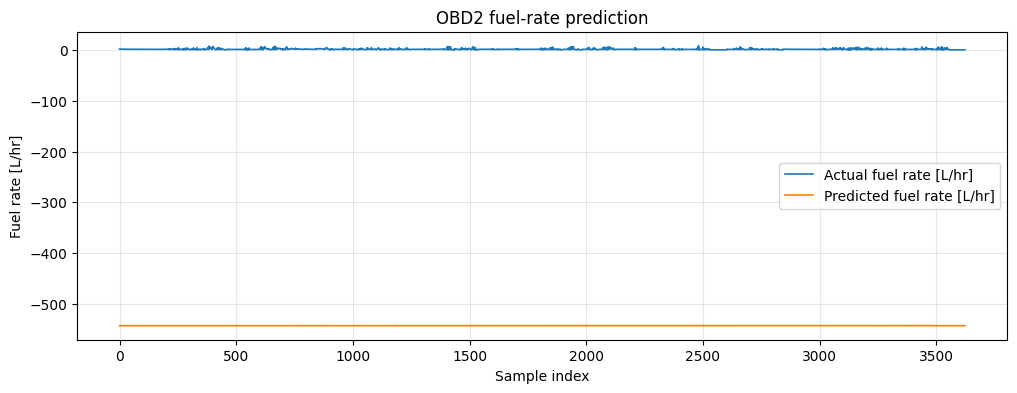

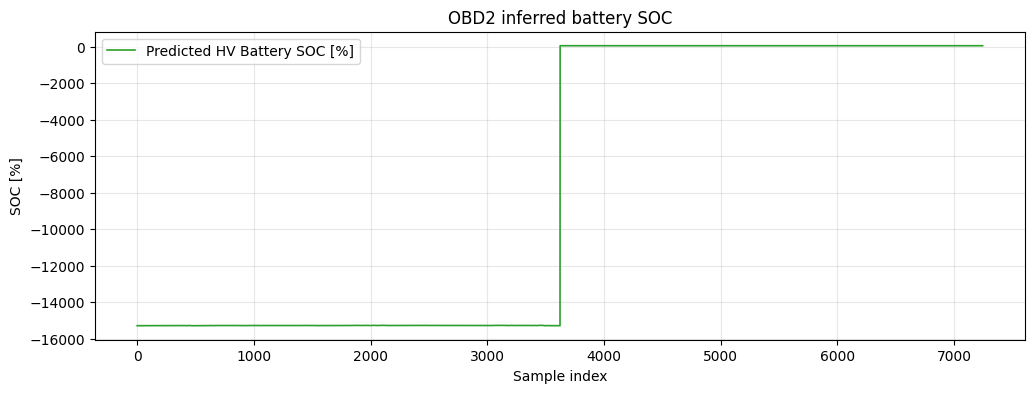

Saved predictions to: /content/drive/MyDrive/Data/VED-dataset/ved_obd2_predictions.csv


In [4]:
if 'Actual Fuel Rate [L/hr]' in predictions_df.columns:
    fuel_mask = predictions_df['Actual Fuel Rate [L/hr]'].notna() & np.isfinite(predictions_df['Predicted Fuel Rate [L/hr]'])

    if fuel_mask.any():
        actual = predictions_df.loc[fuel_mask, 'Actual Fuel Rate [L/hr]']
        predicted = predictions_df.loc[fuel_mask, 'Predicted Fuel Rate [L/hr]']

        fuel_mse = mean_squared_error(actual, predicted)
        fuel_rmse = np.sqrt(fuel_mse)
        fuel_mae = mean_absolute_error(actual, predicted)
        fuel_r2 = r2_score(actual, predicted)

        print('OBD2 fuel-rate metrics')
        print(f'MSE:  {fuel_mse:.4f}')
        print(f'RMSE: {fuel_rmse:.4f}')
        print(f'MAE:  {fuel_mae:.4f}')
        print(f'R2:   {fuel_r2:.4f}')

        plt.figure(figsize=(12, 4))
        plt.plot(actual.to_numpy(), label='Actual fuel rate [L/hr]', linewidth=1.2)
        plt.plot(predicted.to_numpy(), label='Predicted fuel rate [L/hr]', linewidth=1.2)
        plt.title('OBD2 fuel-rate prediction')
        plt.xlabel('Sample index')
        plt.ylabel('Fuel rate [L/hr]')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

if 'Predicted HV Battery SOC [%]' in predictions_df.columns:
    plt.figure(figsize=(12, 4))
    plt.plot(predictions_df['Predicted HV Battery SOC [%]'].to_numpy(), label='Predicted HV Battery SOC [%]', color='tab:green', linewidth=1.2)
    plt.title('OBD2 inferred battery SOC')
    plt.xlabel('Sample index')
    plt.ylabel('SOC [%]')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

predictions_df.to_csv(PREDICTIONS_OUTPUT_PATH, index=False)
print('Saved predictions to:', PREDICTIONS_OUTPUT_PATH)